# Backtesting

Imports

In [23]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Load cointegration data and confirm structure/results

In [24]:
data_folder_path = Path("data")
print(data_folder_path.exists())

True


In [25]:
coint_results = pd.read_parquet(data_folder_path / "cointegration_results.parquet")

In [26]:
print(coint_results)

                                 correlation   coint_t   p_value  \
formation_end ticker_0 ticker_1                                    
2016-01-01    STT      GS           0.753596 -3.368117  0.046017   
                       MS           0.739525 -4.754344  0.000454   
                       LNC          0.776851 -3.429478  0.039180   
              COP      EOG          0.781141 -4.284543  0.002706   
              KIM      O            0.762781 -4.291778  0.002637   
...                                      ...       ...       ...   
2026-01-01    GS       MS           0.863687 -3.476624  0.034525   
              JPM      COF          0.712321 -3.905996  0.009732   
              MET      MTB          0.704736 -4.470129  0.001371   
              AXP      MS           0.704349 -4.460528  0.001421   
              COF      WFC          0.741562 -3.723350  0.017097   

                                 critical_1pct  critical_5pct  critical_10pct  \
formation_end ticker_0 ticker_1   

In [27]:
coint_results.shape
coint_results.index.names
coint_results.head()
coint_results.tail()
coint_results.isna().sum()

correlation       0
coint_t           0
p_value           0
critical_1pct     0
critical_5pct     0
critical_10pct    0
n_observations    0
dtype: int64

In [28]:
pairs_per_month = coint_results.groupby(level="formation_end").size()

pairs_per_month.describe()

count     121.000000
mean      138.553719
std       166.671631
min        21.000000
25%        48.000000
50%        76.000000
75%       118.000000
max      1006.000000
dtype: float64

In [29]:
pairs_per_month.sort_values(ascending=False).head(15)

formation_end
2022-02-01    1006
2022-03-01     878
2022-01-01     714
2021-10-01     521
2021-12-01     496
2021-11-01     457
2021-09-01     432
2021-07-01     414
2021-08-01     409
2022-04-01     392
2021-06-01     368
2020-10-01     365
2020-07-01     357
2021-05-01     343
2021-04-01     342
dtype: int64

<Axes: title={'center': 'Cointegrated Pairs per Formation Window'}, xlabel='formation_end'>

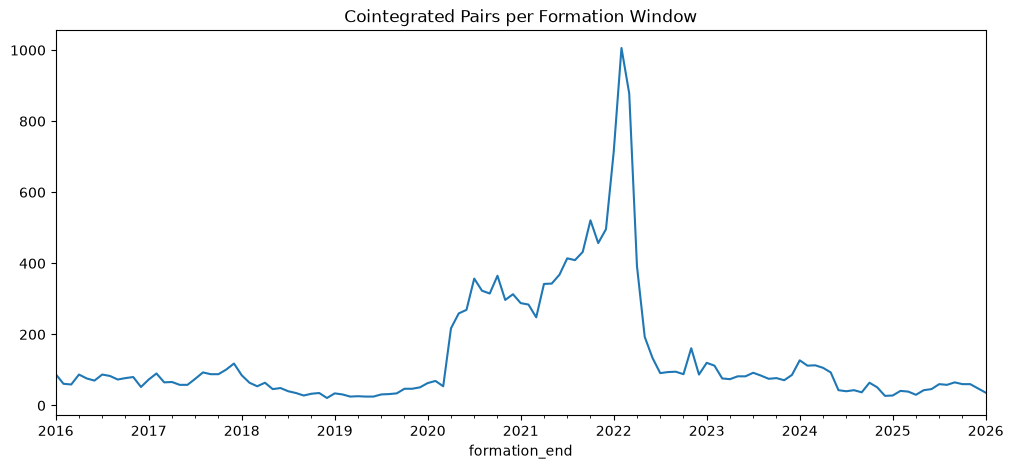

In [30]:
pairs_per_month.plot(
    title="Cointegrated Pairs per Formation Window",
    figsize=(12, 5)
)

In [33]:
peak_date = pairs_per_month.idxmax()

peak_pairs = coint_results.xs(
    peak_date,
    level="formation_end"
)

peak_pairs[["correlation", "p_value", "coint_t"]].describe()

,correlation,p_value,coint_t
count,1006.000000,1006.000000,1006.000000
mean,0.754388,0.017485,-3.953175
std,0.051339,0.015330,0.540014
min,0.700025,0.000001,-6.019675
25%,0.714320,0.003354,-4.223983
50%,0.736170,0.014143,-3.786154
75%,0.780570,0.030025,-3.527612
max,0.981191,0.049886,-3.336680


In [34]:
normal = coint_results.xs(
    pd.Timestamp("2019-01-01"),
    level="formation_end"
)

normal[["correlation", "p_value", "coint_t"]].describe()

,correlation,p_value,coint_t
count,34.000000,34.000000,34.000000
mean,0.792878,0.024880,-3.721473
std,0.076244,0.015767,0.395374
min,0.702476,0.000460,-4.750830
25%,0.729220,0.011181,-3.862248
50%,0.779476,0.024363,-3.602185
75%,0.838772,0.037207,-3.448857
max,0.971434,0.049909,-3.336498
